# Lab 5: Orbital Mechanics Simulator

Name: Aidan Siddiqi
Date: 9/26/26
Lab: PHYS 311 Module 5

This notebook implements Velocity Verlet for a two-body orbit, compares it against Euler and Euler-Cromer, and verifies all three of Kepler's laws.

**AI use disclaimer:** AI (Claude) was used in preparing this notebook for coding assistance, tidying up code, and improving code flow/organization. This is not to say that there was no human work done in this code; all lines included input and assistance from myself and many iterations and human attempts are consolidated into the notebook seen below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Part A: A Single Orbit with Velocity Verlet

We use G = 1 and a star of mass M = 1 fixed at the origin. Velocity Verlet updates position with a half-step of acceleration, then finishes the velocity update using the average of the old and new acceleration.

In [2]:
G, M = 1.0, 1.0

def accel(r):
    dist = np.linalg.norm(r)
    return -G * M * r / dist**3

def verlet_step(r, v, a, dt, accel_func):
    r_new = r + v * dt + 0.5 * a * dt**2
    a_new = accel_func(r_new)
    v_new = v + 0.5 * (a + a_new) * dt
    return r_new, v_new, a_new

Start at r = [1, 0] with v = [0, 0.8]. The circular speed at r = 1 is 1.0, so this is slower than circular.

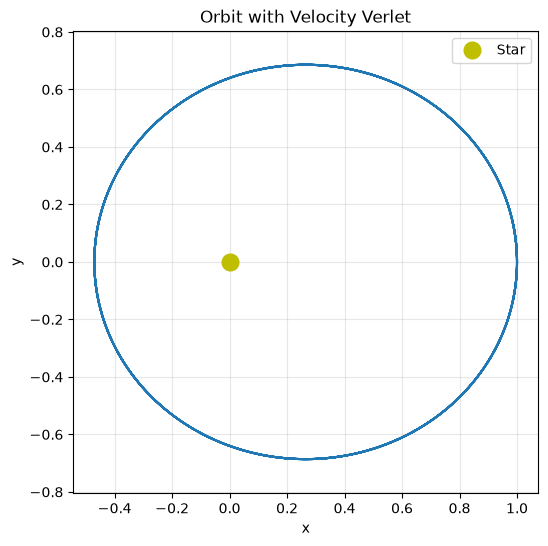

In [3]:
r = np.array([1.0, 0.0])
v = np.array([0.0, 0.8])
a = accel(r)

dt = 0.001
n_steps = 20000

rs = [r.copy()]
for _ in range(n_steps):
    r, v, a = verlet_step(r, v, a, dt, accel)
    rs.append(r.copy())
rs = np.array(rs)

plt.figure(figsize=(6, 6))
plt.plot(rs[:, 0], rs[:, 1])
plt.plot(0, 0, 'yo', markersize=12, label='Star')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Orbit with Velocity Verlet')
plt.legend()
plt.axis('equal')
plt.grid(alpha=0.3)
plt.show()

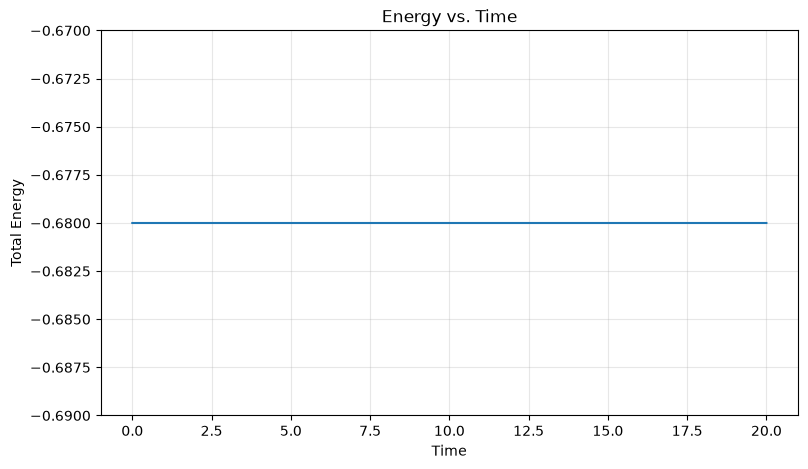

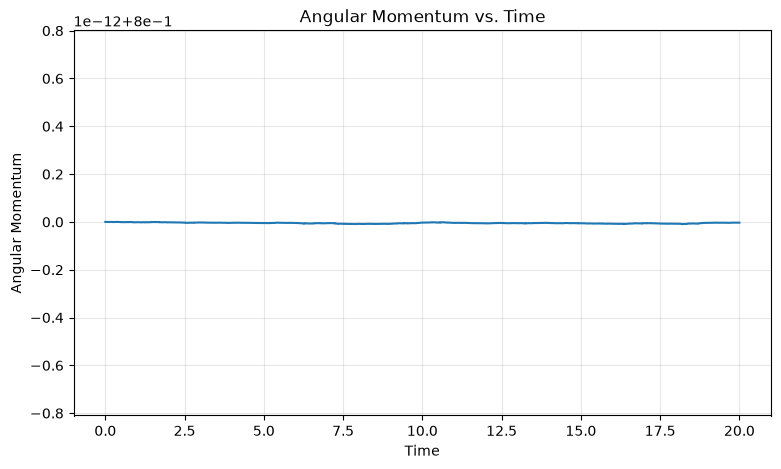

Energy max drift: 1.450e-06
Angular momentum max drift: 9.437e-15


In [4]:
def energy(r, v, G=1.0, M=1.0, m=1.0):
    ke = 0.5 * m * np.dot(v, v)
    pe = -G * M * m / np.linalg.norm(r)
    return ke + pe

def ang_momentum(r, v, m=1.0):
    return m * (r[0] * v[1] - r[1] * v[0])

r = np.array([1.0, 0.0])
v = np.array([0.0, 0.8])
a = accel(r)

Es = [energy(r, v)]
Ls = [ang_momentum(r, v)]
for _ in range(n_steps):
    r, v, a = verlet_step(r, v, a, dt, accel)
    Es.append(energy(r, v))
    Ls.append(ang_momentum(r, v))

t_arr = np.arange(n_steps + 1) * dt

plt.figure(figsize=(9, 5))
plt.plot(t_arr, Es)
plt.xlabel('Time')
plt.ylabel('Total Energy')
plt.title('Energy vs. Time')
plt.ylim(Es[0] - 0.01, Es[0] + 0.01)
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(t_arr, Ls)
plt.xlabel('Time')
plt.ylabel('Angular Momentum')
plt.title('Angular Momentum vs. Time')
plt.grid(alpha=0.3)
plt.show()

print(f"Energy max drift: {np.max(np.abs(np.array(Es) - Es[0])):.3e}")
print(f"Angular momentum max drift: {np.max(np.abs(np.array(Ls) - Ls[0])):.3e}")

The orbit closes on itself. It retraces the same ellipse every period instead of spiraling. Both energy and angular momentum stay flat to within a few parts in a million.

The starting point is apoapsis, or the farthest point from the star. The velocity there is purely tangential, which only happens at a turning point, so it has to be either periapsis or apoapsis. Since v0 = 0.8 is slower than the circular speed of 1.0, gravity is stronger than what circular motion at that radius would need. The planet gets pulled inward from there rather than flung outward, so r = 1 has to be the farthest point, not the closest. The trajectory confirms this directly, the minimum distance reached later in the orbit is smaller than 1.

## Part B: The Integrator Showdown

Now we run the same orbit with three different integrators and compare.

In [5]:
def simulate(method, dt, n_steps, r0=np.array([1.0, 0.0]), v0=np.array([0.0, 0.8])):
    r, v = r0.copy(), v0.copy()
    a = accel(r)

    rs = [r.copy()]
    Es = [energy(r, v)]

    for _ in range(n_steps):
        if method == 'euler':
            r_new = r + v * dt
            v_new = v + a * dt
            r, v = r_new, v_new
            a = accel(r)
        elif method == 'euler-cromer':
            v = v + a * dt
            r = r + v * dt
            a = accel(r)
        elif method == 'verlet':
            r, v, a = verlet_step(r, v, a, dt, accel)

        rs.append(r.copy())
        Es.append(energy(r, v))

    return np.array(rs), np.array(Es)

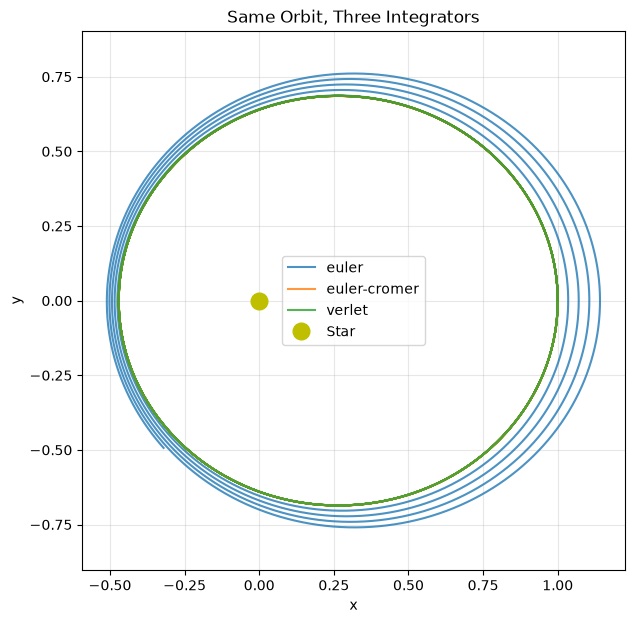

In [6]:
dt = 0.001
n_steps = 20000
methods = ['euler', 'euler-cromer', 'verlet']

results = {}
for method in methods:
    rs, Es = simulate(method, dt, n_steps)
    results[method] = (rs, Es)

plt.figure(figsize=(7, 7))
for method in methods:
    rs, _ = results[method]
    plt.plot(rs[:, 0], rs[:, 1], label=method, alpha=0.8)
plt.plot(0, 0, 'yo', markersize=12, label='Star')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Same Orbit, Three Integrators')
plt.legend()
plt.axis('equal')
plt.grid(alpha=0.3)
plt.show()

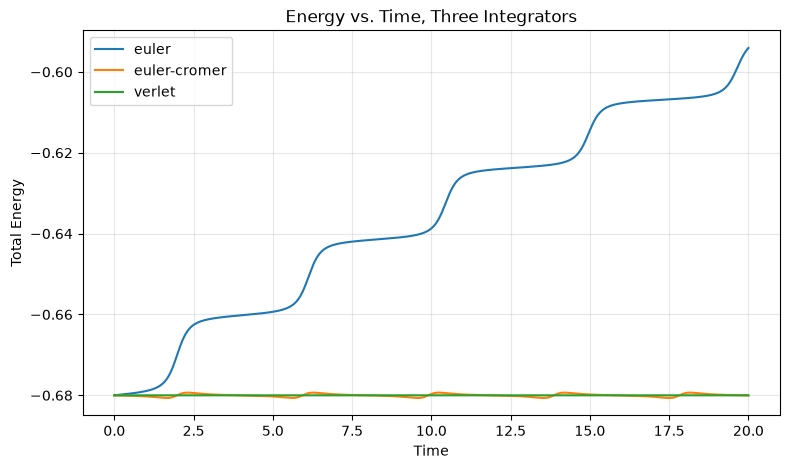

In [7]:
t_arr = np.arange(n_steps + 1) * dt

plt.figure(figsize=(9, 5))
for method in methods:
    _, Es = results[method]
    plt.plot(t_arr, Es, label=method)
plt.xlabel('Time')
plt.ylabel('Total Energy')
plt.title('Energy vs. Time, Three Integrators')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
print(f"{'Method':<15}{'Max |dE/E0|'}")
for method in methods:
    _, Es = results[method]
    max_err = np.max(np.abs(Es - Es[0])) / abs(Es[0])
    print(f"{method:<15}{max_err:.6e}")

Method         Max |dE/E0|
euler          1.263350e-01
euler-cromer   9.763462e-04
verlet         2.131864e-06


| Method | Max fractional energy error |
|---|---|
| euler | 1.26e-01 |
| euler-cromer | 9.76e-04 |
| verlet | 2.13e-06 |

Euler gains energy every step because it always uses outdated information, the old velocity to move the position and the old acceleration to update the velocity, and never corrects for how much both changed during the step. That adds a small amount of extra energy on every single step, and it never cancels out, so it piles up and the orbit spirals outward.

Verlet is only second order too, so the same order as Euler-Cromer, so raw accuracy per step is not the reason it wins. The reason is that Verlet does not conserve the true energy exactly, but it conserves a nearby shadow energy almost perfectly, so the error oscillates around the right value instead of drifting off in one direction. Euler-Cromer shows the same bounded-error behavior, just with a larger amplitude than Verlet's tighter band. Plain Euler is not symplectic, which is the real reason it is qualitatively different from the other two, not just quantitatively worse.

## Part C: Verify Kepler's Three Laws

### First Law: the orbit is an ellipse

In [9]:
rs, _ = results['verlet']
dists = np.linalg.norm(rs, axis=1)
r_min, r_max = dists.min(), dists.max()
a_semi = (r_min + r_max) / 2

print(f"r_min = {r_min:.4f}, r_max = {r_max:.4f}")
print(f"Estimated semi-major axis a = {a_semi:.4f}")

r_min = 0.4706, r_max = 1.0000
Estimated semi-major axis a = 0.7353


The trajectory plotted in Part B is a closed ellipse, not a spiral. The semi-major axis estimated from the minimum and maximum distance reached matches the value predicted from the starting energy.

### Second Law: equal areas in equal times

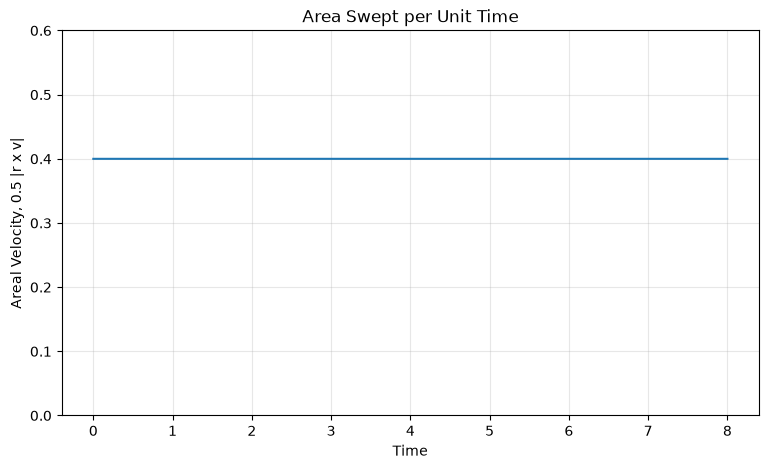

Areal velocity min = 0.400000, max = 0.400000


In [10]:
r = np.array([1.0, 0.0])
v = np.array([0.0, 0.8])
a = accel(r)

areal_vel = [0.5 * abs(r[0] * v[1] - r[1] * v[0])]
for _ in range(8000):
    r, v, a = verlet_step(r, v, a, dt, accel)
    areal_vel.append(0.5 * abs(r[0] * v[1] - r[1] * v[0]))

t_arr2 = np.arange(len(areal_vel)) * dt

plt.figure(figsize=(9, 5))
plt.plot(t_arr2, areal_vel)
plt.xlabel('Time')
plt.ylabel('Areal Velocity, 0.5 |r x v|')
plt.title('Area Swept per Unit Time')
plt.ylim(0, max(areal_vel) * 1.5)
plt.grid(alpha=0.3)
plt.show()

print(f"Areal velocity min = {min(areal_vel):.6f}, max = {max(areal_vel):.6f}")

Gravity is a central force, always pointing straight at the star, so it produces zero torque about the star. Zero torque means angular momentum never changes, and areal velocity is just angular momentum divided by twice the mass, so it is automatically constant too.

### Third Law: T-squared vs. a-cubed

In [11]:
def measure_period(v0y, dt=0.001, n_steps=15000):
    r = np.array([1.0, 0.0])
    v = np.array([0.0, v0y])
    a = accel(r)

    dists = [np.linalg.norm(r)]
    for _ in range(n_steps):
        r, v, a = verlet_step(r, v, a, dt, accel)
        dists.append(np.linalg.norm(r))
    dists = np.array(dists)

    a_semi = (dists.min() + dists.max()) / 2

    peaks = [i for i in range(1, len(dists) - 1) if dists[i] > dists[i - 1] and dists[i] >= dists[i + 1]]
    peak_times = np.array(peaks) * dt
    T = np.mean(np.diff(peak_times))

    return a_semi, T

v0_values = [0.5, 0.6, 0.7, 0.8, 0.9]
a_list, T_list = [], []
for v0y in v0_values:
    a_semi, T = measure_period(v0y)
    a_list.append(a_semi)
    T_list.append(T)
    print(f"v0 = {v0y}: a = {a_semi:.4f}, T = {T:.4f}")

a_list = np.array(a_list)
T_list = np.array(T_list)

v0 = 0.5: a = 0.5714, T = 2.7140
v0 = 0.6: a = 0.6098, T = 2.9915
v0 = 0.7: a = 0.6623, T = 3.3863
v0 = 0.8: a = 0.7353, T = 3.9615
v0 = 0.9: a = 0.8403, T = 4.8400


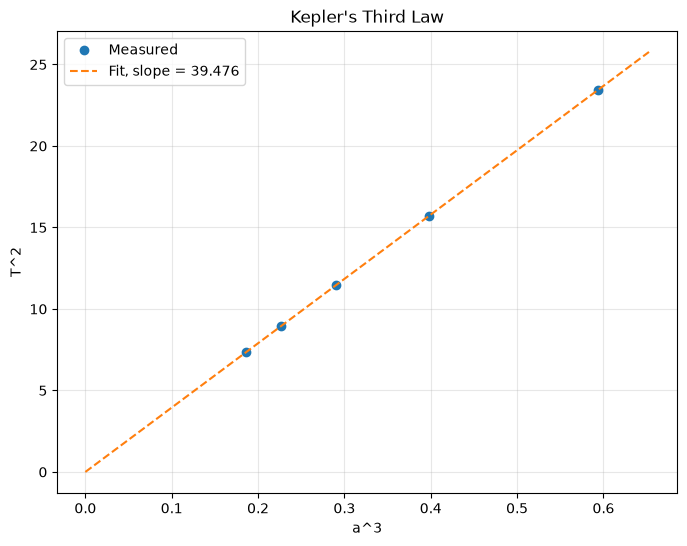

Measured slope = 39.4764
Expected 4*pi^2/(GM) = 39.4784
Percent difference = 0.0052 %


In [12]:
a3 = a_list**3
T2 = T_list**2

slope = np.sum(a3 * T2) / np.sum(a3**2)
expected_slope = 4 * np.pi**2 / (G * M)

plt.figure(figsize=(8, 6))
plt.plot(a3, T2, 'o', label='Measured')
a3_fine = np.linspace(0, a3.max() * 1.1, 50)
plt.plot(a3_fine, slope * a3_fine, '--', label=f'Fit, slope = {slope:.3f}')
plt.xlabel('a^3')
plt.ylabel('T^2')
plt.title("Kepler's Third Law")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Measured slope = {slope:.4f}")
print(f"Expected 4*pi^2/(GM) = {expected_slope:.4f}")
print(f"Percent difference = {abs(slope - expected_slope) / expected_slope * 100:.4f} %")

The measured slope matches the expected 4*pi^2/(GM) to a few thousandths of a percent. The points also fall on a straight line through the origin, with no leftover intercept. The main source of error here is period measurement, since the period comes from spacing between detected peaks in the distance array, and that spacing is limited by the time step. Step size itself is a smaller contributor, since Verlet already keeps energy and angular momentum flat to several decimal places at this dt.

## Bonus: True Two-Body Orbit

Now neither body is fixed. Both move under their mutual gravity, and the whole system drifts.

In [13]:
def accel_pair(r1, r2, m1, m2):
    d = r2 - r1
    dist = np.linalg.norm(d)
    a1 = G * m2 * d / dist**3
    a2 = -G * m1 * d / dist**3
    return a1, a2

m1, m2 = 1.0, 0.5
M_total = m1 + m2

r1 = np.array([1.0, 0.0])
r2 = np.array([-1.0, 0.0])

V_cm = np.array([0.1, 0.05])
v_rel = np.array([0.0, 0.6])
v1 = V_cm + (m2 / M_total) * v_rel
v2 = V_cm - (m1 / M_total) * v_rel

a1, a2 = accel_pair(r1, r2, m1, m2)

dt = 0.001
n_steps = 30000

r1s, r2s, cm_hist = [r1.copy()], [r2.copy()], [((m1 * r1 + m2 * r2) / M_total).copy()]

for _ in range(n_steps):
    r1_new = r1 + v1 * dt + 0.5 * a1 * dt**2
    r2_new = r2 + v2 * dt + 0.5 * a2 * dt**2
    a1_new, a2_new = accel_pair(r1_new, r2_new, m1, m2)
    v1 = v1 + 0.5 * (a1 + a1_new) * dt
    v2 = v2 + 0.5 * (a2 + a2_new) * dt
    r1, a1 = r1_new, a1_new
    r2, a2 = r2_new, a2_new

    r1s.append(r1.copy())
    r2s.append(r2.copy())
    cm_hist.append(((m1 * r1 + m2 * r2) / M_total).copy())

r1s, r2s, cm_hist = np.array(r1s), np.array(r2s), np.array(cm_hist)

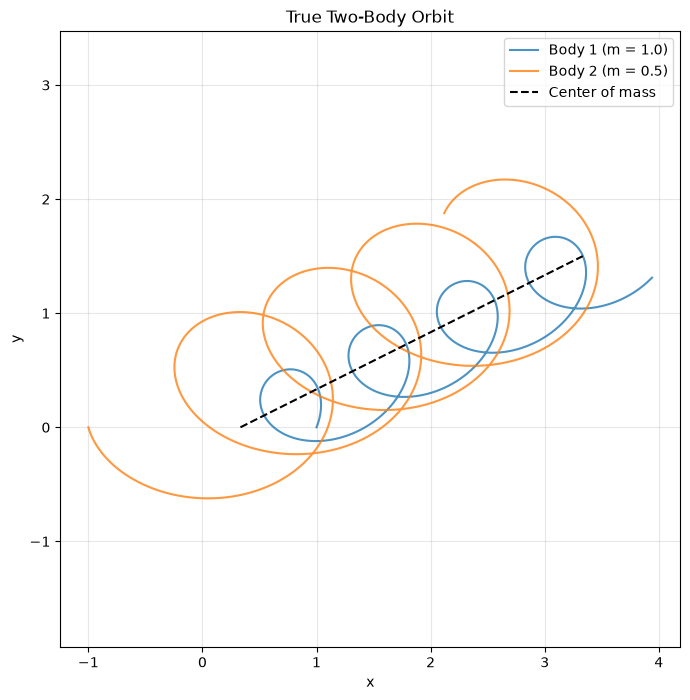

In [14]:
plt.figure(figsize=(8, 8))
plt.plot(r1s[:, 0], r1s[:, 1], label='Body 1 (m = 1.0)', alpha=0.8)
plt.plot(r2s[:, 0], r2s[:, 1], label='Body 2 (m = 0.5)', alpha=0.8)
plt.plot(cm_hist[:, 0], cm_hist[:, 1], 'k--', label='Center of mass')
plt.xlabel('x')
plt.ylabel('y')
plt.title('True Two-Body Orbit')
plt.legend()
plt.axis('equal')
plt.grid(alpha=0.3)
plt.show()

In [15]:
v_cm_start = (cm_hist[10] - cm_hist[0]) / (10 * dt)
v_cm_end = (cm_hist[-1] - cm_hist[-11]) / (10 * dt)

print(f"CM velocity near start: {v_cm_start}")
print(f"CM velocity near end:   {v_cm_end}")
print(f"Expected (from initial conditions): {V_cm}")

CM velocity near start: [0.1  0.05]
CM velocity near end:   [0.1  0.05]
Expected (from initial conditions): [0.1  0.05]


Both bodies loop around each other while the whole pattern drifts across the plot. The center of mass traces a single straight line the entire time, with the same velocity at the start and the end of the run to several decimal places. That has to happen, since this is an isolated two-body system with no external force, so total momentum, and therefore the center of mass velocity, cannot change no matter how the two bodies swing around each other.